# 02 · Financing mix (Q2)

**Question (docs/01 §3, Q2).** How much of the market is financed, mortgage vs cash and off-plan vs ready, and has that shifted with interest rates?

**Definitions (docs/01 §4).**
- *Mortgage share* = individual new mortgages (Mortgage Registration, Delayed Mortgage, Mortgage Pre-Registration) ÷ (new mortgages + market sales).
- *Portfolio mortgages* (one loan over several units) are outside the share and shown separately, counted once per deal.
- *Off-plan share* = off-plan market sales ÷ market sales, by count and by value.
- *Observed LTV* = loan ÷ price for a mortgage and a sale of the same unit on the same day (the Phase 1 match, rebuilt on gold). It covers purchase mortgages only.

**Rates.** EIBOR is not loaded yet, so the effective **Fed Funds** rate stands in (the AED is pegged to the USD). Correlations here are associations, not causal effects.

**Scope.** 2004-01-01 to 2026-09-25; **2026 is partial**. As notebook 01 shows, 2004–2010 volumes are distorted by registration timing, so rate comparisons start in 2010.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from dubai_property import config
from dubai_property.analysis import common
from dubai_property.analysis import financing as fi
from dubai_property.analysis import market_cycles as mc
from dubai_property.analysis import plotting as P

P.apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
SNAP = common.snapshot_date()
START = config.REPORT_SCOPE_START
print("Data snapshot:", SNAP)

Data snapshot: 2026-09-25


## 1. Mortgage share vs the Fed Funds rate

In [2]:
share = fi.mortgage_share_monthly(START, SNAP)
corr = fi.share_rate_correlation(share, from_year=2010)
print({k: round(v, 3) for k, v in corr.items()})
yearly_share = share.groupby(share["month"].dt.year)[["new_mortgages", "market_sales"]].sum()
yearly_share["mortgage_share"] = yearly_share["new_mortgages"] / yearly_share.sum(axis=1)
rate_y = share.groupby(share["month"].dt.year)["fed_funds_rate"].mean()
display(yearly_share.join(rate_y.rename("fed_funds_avg")).loc[2010:])

{'months': 200.0, 'corr_levels': -0.234, 'corr_12m_changes': -0.205}


,new_mortgages,market_sales,mortgage_share,fed_funds_avg
month,,,,
2010,"7,311.000","30,185.000",0.195,0.002
2011,"6,022.000","24,891.000",0.195,0.001
2012,"5,250.000","32,546.000",0.139,0.001
2013,"8,091.000","58,159.000",0.122,0.001
2014,"8,088.000","50,163.000",0.139,0.001
2015,"9,099.000","38,436.000",0.191,0.001
2016,"10,079.000","37,742.000",0.211,0.004
2017,"11,144.000","42,831.000",0.206,0.010
2018,"9,962.000","29,712.000",0.251,0.018


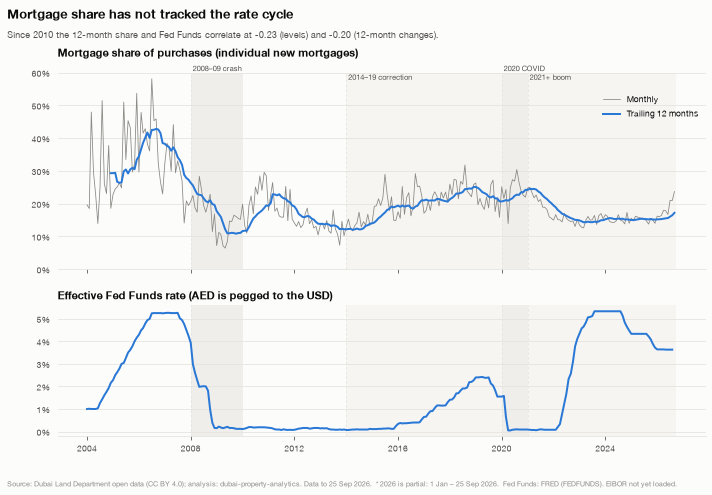

In [3]:
fig, (a1, a2) = P.figure(2, 1, size=(10, 6.8), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
fig.subplots_adjust(top=0.86, bottom=0.11, hspace=0.22)
for ax in (a1, a2):
    P.shade_phases(ax, mc.CYCLE_PHASES, SNAP, by="month", label=ax is a1)
a1.plot(share["month"], share["mortgage_share"], color=P.MUTED, lw=0.8, label="Monthly")
a1.plot(
    share["month"],
    share["mortgage_share_12m"],
    color=P.SERIES["total"],
    lw=2,
    label="Trailing 12 months",
)
P.pct_axis(a1)
a1.set_ylim(0, 0.6)
a1.set_title("Mortgage share of purchases (individual new mortgages)", pad=16)
a1.legend(loc="upper right", bbox_to_anchor=(1, 0.93))
a2.plot(share["month"], share["fed_funds_rate"], color=P.SERIES["total"], lw=2)
P.pct_axis(a2, decimals=0)
a2.set_title("Effective Fed Funds rate (AED is pegged to the USD)")
P.titled(
    fig,
    "Mortgage share has not tracked the rate cycle",
    f"Since 2010 the 12-month share and Fed Funds correlate at {corr['corr_levels']:.2f} (levels) "
    f"and {corr['corr_12m_changes']:.2f} (12-month changes).",
)
P.add_source(fig, SNAP, note="Fed Funds: FRED (FEDFUNDS). EIBOR not yet loaded.")
P.save(fig, "q2_mortgage_share_vs_fedfunds")
plt.show()

## 2. Off-plan share of market sales

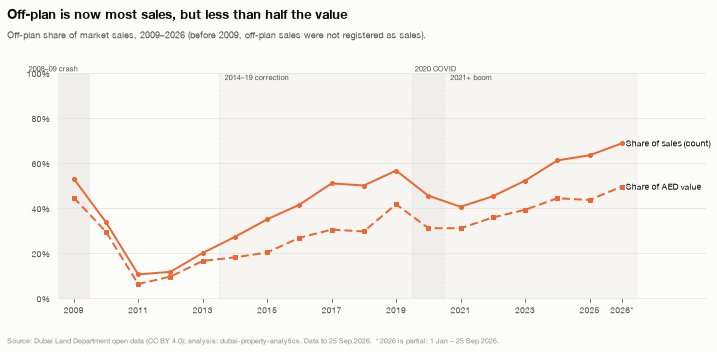

In [4]:
yearly = mc.sales_by_year(START, SNAP)
fig, ax = P.figure(size=(10, 4.8))
P.shade_phases(ax, mc.CYCLE_PHASES, SNAP)
y = yearly[yearly["year"] >= 2009]
ax.plot(y["year"], y["offplan_share_count"], color=P.SERIES["offplan"], marker="o", ms=4)
ax.plot(
    y["year"], y["offplan_share_value"], color=P.SERIES["offplan"], ls=(0, (4, 2)), marker="s", ms=4
)
last = y.iloc[-1]
P.direct_label(ax, last["year"], last["offplan_share_count"], "Share of sales (count)")
P.direct_label(ax, last["year"], last["offplan_share_value"], "Share of AED value")
P.pct_axis(ax)
ax.set_ylim(0, 1)
ax.set_xlim(2008.5, SNAP.year + 2.6)
P.year_ticks(ax, y["year"], SNAP)
P.titled(
    fig,
    "Off-plan is now most sales, but less than half the value",
    "Off-plan share of market sales, 2009–2026 (before 2009, off-plan sales were not registered as sales).",
)
P.add_source(fig, SNAP)
P.save(fig, "q2_offplan_share_count_value")
plt.show()

## 3. Observed loan-to-value (LTV) by year

A same-day mortgage and sale of the same unit, keyed on date, area, building, project, sq m, rooms, type and sub-type, and unique on both sides. The mass of the distribution sits at the regulatory caps, which is what showed in Phase 1 that `actual_worth` on these mortgage rows is the loan amount.

In [5]:
ltv = fi.ltv_by_year()
display(ltv.set_index("year"))

,pairs,p25,median,p75,share_at_0_75,share_at_0_80,share_at_0_848,share_0_80_to_1,share_above_1
year,,,,,,,,,
2004,146,0.623,0.750,0.999,0.034,0.027,0.000,0.233,0.164
2005,161,0.660,0.786,1.000,0.068,0.031,0.000,0.255,0.211
2006,303,0.680,0.769,1.000,0.013,0.036,0.000,0.254,0.175
2007,836,0.672,0.800,0.900,0.043,0.092,0.000,0.267,0.154
2008,1786,0.711,0.839,1.093,0.038,0.071,0.002,0.264,0.278
2009,1600,0.700,0.804,0.997,0.065,0.071,0.001,0.256,0.243
2010,1791,0.700,0.800,0.923,0.064,0.083,0.001,0.243,0.213
2011,1572,0.699,0.790,0.850,0.075,0.144,0.001,0.222,0.122
2012,1917,0.700,0.776,0.808,0.087,0.200,0.002,0.150,0.100


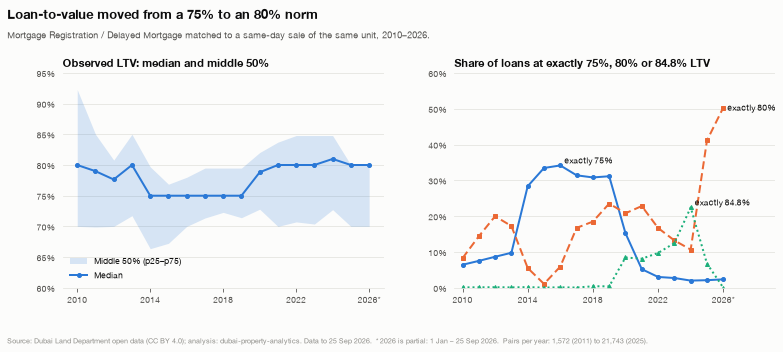

In [6]:
fig, (a1, a2) = P.figure(1, 2, size=(11, 4.8))
fig.subplots_adjust(top=0.8, bottom=0.17, wspace=0.22)
lt = ltv[ltv["year"] >= 2010]
a1.fill_between(
    lt["year"],
    lt["p25"],
    lt["p75"],
    color=P.SERIES["total"],
    alpha=0.18,
    lw=0,
    label="Middle 50% (p25–p75)",
)
a1.plot(lt["year"], lt["median"], color=P.SERIES["total"], marker="o", ms=4, label="Median")
a1.set_ylim(0.6, 0.95)
a1.set_title("Observed LTV: median and middle 50%")
P.pct_axis(a1)
a1.legend(loc="lower left")
P.year_ticks(a1, lt["year"], SNAP, step=4)
a2.plot(lt["year"], lt["share_at_0_75"], color=P.SERIES["ready"], marker="o", ms=4)
a2.plot(
    lt["year"], lt["share_at_0_80"], color=P.SERIES["offplan"], marker="s", ms=4, ls=(0, (4, 2))
)
a2.plot(
    lt["year"], lt["share_at_0_848"], color=P.SERIES["third"], marker="^", ms=4, ls=(0, (1, 1.5))
)
P.direct_label(
    a2, 2024, lt.set_index("year").loc[2024, "share_at_0_848"], "exactly 84.8%", va="bottom"
)
P.direct_label(
    a2, 2016, lt.set_index("year").loc[2016, "share_at_0_75"], "exactly 75%", va="bottom"
)
P.direct_label(a2, lt["year"].iloc[-1], lt["share_at_0_80"].iloc[-1], "exactly 80%")
P.pct_axis(a2)
a2.set_ylim(0, 0.6)
a2.set_xlim(2009.5, SNAP.year + 3.2)
a2.set_title("Share of loans at exactly 75%, 80% or 84.8% LTV")
P.year_ticks(a2, lt["year"], SNAP, step=4)
P.titled(
    fig,
    "Loan-to-value moved from a 75% to an 80% norm",
    "Mortgage Registration / Delayed Mortgage matched to a same-day sale of the same unit, 2010–2026.",
)
P.add_source(fig, SNAP, note="Pairs per year: 1,572 (2011) to 21,743 (2025).")
P.save(fig, "q2_ltv_by_year")
plt.show()

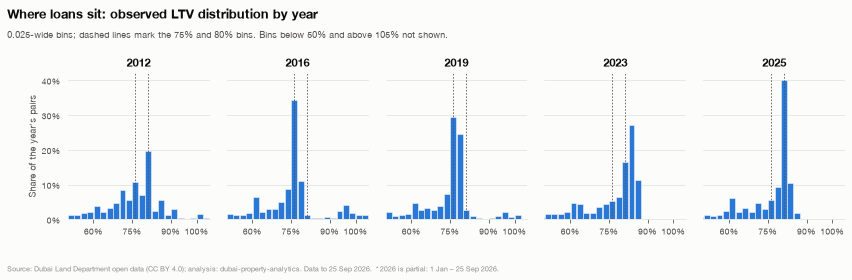

In [7]:
years = [2012, 2016, 2019, 2023, 2025]
hist = fi.ltv_histogram(years)
fig, axes = P.figure(1, len(years), size=(12, 3.8), sharey=True)
fig.subplots_adjust(top=0.74, bottom=0.2, wspace=0.12)
for ax, yr in zip(axes, years, strict=True):
    h = hist[(hist["year"] == yr) & hist["bucket"].between(1, 28)]
    ax.bar(
        h["ltv_low"] + 0.0125,
        h["share"],
        width=0.023,
        color=P.SERIES["total"],
        edgecolor=P.SURFACE,
        lw=0.5,
    )
    for cap in (0.75, 0.80):
        ax.axvline(cap + 0.0125, color=P.TEXT_2, lw=0.8, ls=(0, (2, 2)))
    ax.set_title(P.year_label(yr, SNAP), loc="center")
    ax.set_xlim(0.5, 1.05)
    ax.set_xticks([0.6, 0.75, 0.9, 1.0])
    ax.set_xticklabels(["60%", "75%", "90%", "100%"])
    ax.grid(False, axis="x")
P.pct_axis(axes[0])
axes[0].set_ylabel("Share of the year's pairs")
P.titled(
    fig,
    "Where loans sit: observed LTV distribution by year",
    "0.025-wide bins; dashed lines mark the 75% and 80% bins. Bins below 50% and above 105% not shown.",
)
P.add_source(fig, SNAP)
P.save(fig, "q2_ltv_distribution_by_year")
plt.show()

## 4. Portfolio mortgages (shown separately)

One registration over several units, often a developer's or an investor's loan. They are **not** in the mortgage share. Deals are counted once and value once per deal (C16). The value is as registered and is not a verified loan amount (C10).

,portfolio_deals,portfolio_lines,portfolio_value_aed,new_mortgages,new_mortgage_loans_aed
year,,,,,
2004,0.000,0.000,0.000,"1,159.000","7,654,294,152.000"
2005,0.000,0.000,0.000,"1,249.000","12,888,827,219.000"
2006,0.000,0.000,0.000,"1,640.000","36,609,078,905.000"
2007,4.000,9.000,"10,712,270,000.000","2,737.000","36,373,860,546.000"
2008,1.000,1.000,"1,928,864,375.000","5,218.000","74,765,712,904.000"
2009,5.000,5.000,"13,609,890,032.000","7,022.000","18,324,081,170.000"
2010,4.000,4.000,"4,610,925,000.000","7,311.000","26,430,337,580.000"
2011,4.000,6.000,"9,549,650,854.000","6,022.000","31,865,116,949.000"
2012,8.000,8.000,"9,933,178,251.000","5,250.000","17,639,484,288.000"


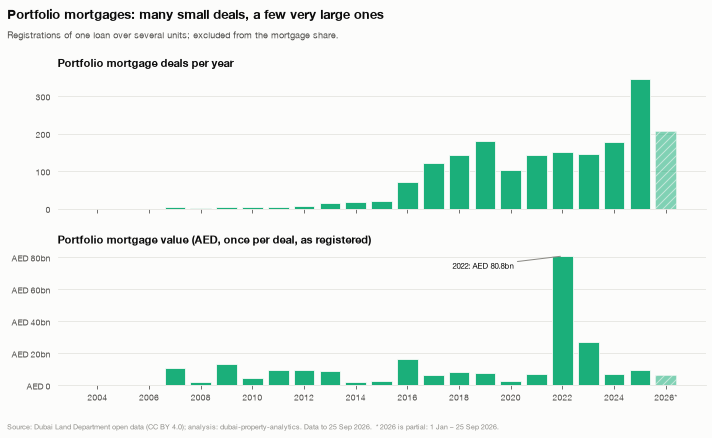

In [8]:
port = fi.portfolio_by_year(START, SNAP)
display(port.set_index("year"))
fig, (a1, a2) = P.figure(2, 1, size=(10, 6), sharex=True)
fig.subplots_adjust(top=0.86, bottom=0.11, hspace=0.3)
P.year_bars(a1, port["year"], port["portfolio_deals"], SNAP, P.SERIES["third"])
a1.set_title("Portfolio mortgage deals per year")
P.count_axis(a1)
P.year_bars(a2, port["year"], port["portfolio_value_aed"], SNAP, P.SERIES["third"])
a2.set_title("Portfolio mortgage value (AED, once per deal, as registered)")
P.aed_axis(a2, prefix=True)
P.year_ticks(a2, port["year"], SNAP)
top = port.loc[port["portfolio_value_aed"].idxmax()]
a2.annotate(
    f"{int(top['year'])}: {P.fmt_aed(top['portfolio_value_aed'])}",
    (top["year"], top["portfolio_value_aed"]),
    xytext=(-110, -5),
    textcoords="offset points",
    fontsize=8,
    va="top",
    arrowprops={"arrowstyle": "-", "color": P.MUTED},
)
P.titled(
    fig,
    "Portfolio mortgages: many small deals, a few very large ones",
    "Registrations of one loan over several units; excluded from the mortgage share.",
)
P.add_source(fig, SNAP)
P.save(fig, "q2_portfolio_mortgages")
plt.show()

## Findings

1. **About one purchase in seven is mortgaged, and the share is rising again.** Mortgage share was 15.0–15.2% every year from 2022 to 2025, down from a 25.1% peak in 2018. It is 18.3% in 2026 to date and 23.7% in September 2026. (2004–07 shares of 27–39% sit on a thin, ready-only register; see notebook 01.)
2. **Rates explain little of the mortgage share.** Since 2010 the trailing-12-month share and the Fed Funds rate correlate at −0.23 in levels and −0.20 in 12-month changes. The 2022–23 hikes (0.1% → 5.3%) coincided with the share falling from 20.2% (2021) to 15.0% (2022), but the 2016–19 hikes coincided with a *rising* share. The boom's volume growth came from cash and off-plan buyers. (Fed Funds stands in for EIBOR, which is not loaded; this is an association only.)
3. **Off-plan is most sales but not most value.** The off-plan share of market sales rose from 40.6% by count (31.0% by value) in 2021 to 63.4% (43.6%) in 2025, and to 68.7% (49.5%) in 2026 to date.
4. **Observed LTVs follow the regulatory caps.** The median loan-to-price ratio was exactly 0.75 every year 2014–2019, with 28–34% of loans at exactly 75%. From 2021 the median is 0.80, and 41.1% (2025) and 50.3% (2026) of loans sit at exactly 80%. A second cluster at exactly **84.8%** appeared in 2020 (8.5% of pairs), peaked at 22.4% in 2024 and vanished in 2026. 0.848 = 0.80 × 1.06, which suggests a loan sized on the price plus costs, but the cause **needs an external source**.
5. **Portfolio mortgages are lumpy and kept separate.** There have been 1,873 deals worth AED 245.0bn (once per deal) since 2004. 2022 alone had AED 80.8bn across 151 deals. Counted in the share, a handful of deals would swing it.